In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astroquery.jplsbdb import SBDB
from pathlib import Path
import glob
import io

import rebound as rb
import reboundx
from reboundx import constants as rbx_constants
import celmech as cm
import assist
import xgboost as xgb

from celmech.miscellaneous import frequency_modified_fourier_transform as fmft
from linear_theory import linear_theory_prediction, make_simpler_secular_theory
from utils import ecliptic_to_icrf, icrf_to_ecliptic, ecliptic_xyz_to_elements, UNIT_CONVER

from tqdm import tqdm

epoch = 2460200.5

Searching NASA Horizons for 'sun'... 
Found: Sun (10) 


In [2]:
### SETUP ASSIST SIMULATION
ephem = assist.Ephem(
    "data/assist/linux_m13000p17000.441",
    "data/assist/sb441-n16.bsp",
)

# Get particle location
d = 'K09WK5U'
sim = rb.Simulation()
sim.add(d, date = "JD%f"%epoch)
p = sim.particles[-1]

# Add it to new sim with the sun
sim = rb.Simulation()
sim.add("Sun", date="JD%f" % epoch)
sim.add(
    x=p.x,
    y=p.y,
    z=p.z,
    vx=p.vx / UNIT_CONVER,
    vy=p.vy / UNIT_CONVER,
    vz=p.vz / UNIT_CONVER,
)

# Convert coordinate frame and units to assist and add it to the sim that we'll actually use to integrate
p = sim.particles[1]
p = ecliptic_to_icrf(p)

# setup assist simulation
sim_a = rb.Simulation()
ex = assist.Extras(sim_a, ephem)

ex.gr_eih_sources = 11
sim_a.ri_ias15.adaptive_mode = 2
sim_a.exit_max_distance = 50.0

# ASSIST time coordinate is relative to ephem.jd_ref
sim_a.t = epoch - ephem.jd_ref

# Add asteroid
sim_a.add(p, plane="frame")

Searching NASA Horizons for 'K09WK5U'... 
Found: 854145 (2009 WU205) 
Searching NASA Horizons for 'Sun'... 


/Users/kdey/.pyenv/versions/3.12.10/envs/proper_elements_prediction/lib/python3.12/site-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


Found: Sun (10) 


/Users/kdey/.pyenv/versions/3.12.10/envs/proper_elements_prediction/lib/python3.12/site-packages/rebound/simulation.py:927: RuntimeWarning: Particle added is from a simulation that uses different units.
  warnings.warn("Particle added is from a simulation that uses different units.", RuntimeWarning)


In [3]:
# Integrate to the list of specified times, keeping track of orbital elements at each iteration
int_time = 5e3 * 365.25

times = np.arange(
    epoch,
    epoch + int_time,
    2048,
)

a_list = []
e_list = []
inc_list = []
Omega_list = []
omega_list = []
time_list_day = [] # time in units of days

for time in times:
    target_time = time - ephem.jd_ref

    ex.integrate_or_interpolate(target_time)

    # convert particle to rebound units
    p_assist = sim_a.particles[-1]
    p_temp = rb.Particle(
        x=p_assist.x,
        y=p_assist.y,
        z=p_assist.z,
        vx=p_assist.vx,
        vy=p_assist.vy,
        vz=p_assist.vz,
	)
    p_temp = icrf_to_ecliptic(p_temp)
    p_temp.vxyz = np.array(p_temp.vxyz) * UNIT_CONVER
    orbit = ecliptic_xyz_to_elements(p_temp)

    time_list_day.append(time)

    a_list.append(orbit.a)
    e_list.append(orbit.e)
    inc_list.append(orbit.inc)
    Omega_list.append(orbit.Omega)
    omega_list.append(orbit.omega)

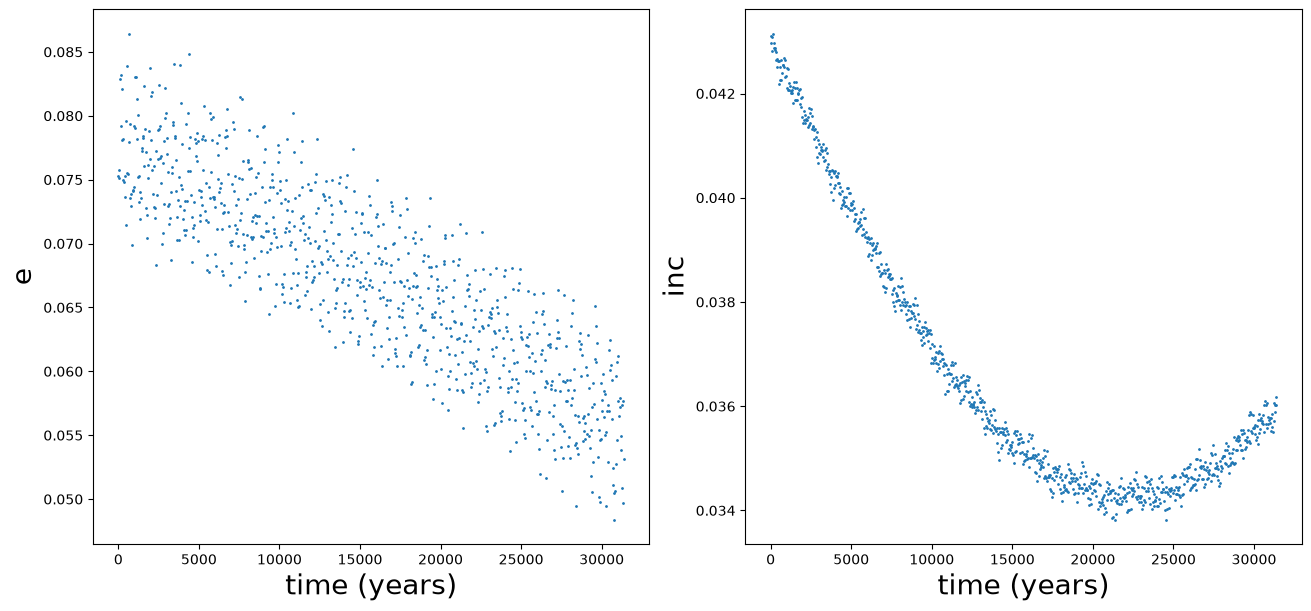

In [4]:
### Plot ECC and INC

# Convert to arrays
time_list_day = np.asarray(time_list_day)
time_list_year = (time_list_day - epoch)/UNIT_CONVER
a_list = np.asarray(a_list)
e_list = np.asarray(e_list)
inc_list = np.asarray(inc_list)
Omega_list = np.asarray(Omega_list)
omega_list = np.asarray(omega_list)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 6), layout="constrained")

ax[0].scatter(time_list_year, e_list, s=1)
ax[0].set_xlabel("time (years)", fontsize = 20)
ax[0].set_ylabel("e", fontsize = 20)

ax[1].scatter(time_list_year, inc_list, s=1)
ax[1].set_xlabel("time (years)", fontsize = 20)
ax[1].set_ylabel("inc", fontsize = 20)

plt.show()

In [5]:
# Calculate ECC and INC FMFT
# prints out as frequency \t amplitude \t phase
X_list = np.sqrt(2*(1-np.sqrt(1-e_list**2))) * np.exp(1j * omega_list)
Y_list = (1- e_list**2)**(0.25) * np.sin(0.5 * inc_list)* np.exp(1j * Omega_list)

ecc_fmft_results = fmft(time_list_year,X_list,14)
planet_e_freqs = np.array(list(ecc_fmft_results.keys()))
planet_e_freqs_arcsec_per_yr = planet_e_freqs * 60*60*180/np.pi * (2*np.pi)

inc_fmft_results = fmft(time_list_year,Y_list,8)
planet_inc_freqs = np.array(list(inc_fmft_results.keys()))
planet_inc_freqs_arcsec_per_yr = planet_inc_freqs * 60*60*180/np.pi * (2*np.pi)

print("")
print(d)
print("g")
print("-------")
for g in planet_e_freqs[:6]:
	print("{:+07.3f} \t {:0.6f} \t {:0.3f}".format(g * 60 * 60 * 180 / np.pi * (2 * np.pi), np.abs(ecc_fmft_results[g]), np.angle(ecc_fmft_results[g])))
print("s")
print("-------")
for g in planet_inc_freqs[:4]:
	print("{:+07.3f} \t {:0.6f} \t {:0.3f}".format(g * 60 * 60 * 180 / np.pi * (2 * np.pi), np.abs(inc_fmft_results[g]), np.angle(inc_fmft_results[g])))


K09WK5U
g
-------
+94.742 	 0.071966 	 1.222
-17326.604 	 0.004051 	 2.859
-305.272 	 0.003819 	 2.439
+104553.865 	 0.002333 	 2.734
-685.105 	 0.001936 	 2.737
-10214.165 	 0.001239 	 -2.381
s
-------
-63.978 	 0.018982 	 -0.106
-404.535 	 0.001758 	 0.542
-794.263 	 0.001142 	 0.225
-1202.435 	 0.000788 	 -0.037


In [ ]:
# create simple rebound sim and add asteroid
# this should be the same initial conditions used in the integration to find harmonics for secular theory
# we use a different integrator, dt, and output cadence to match assist
sim = rb.Simulation()

rebx = reboundx.Extras(sim)
gr = rebx.load_force("gr")
rebx.add_force(gr)
gr.params['c'] = rbx_constants.C

sim.add("Sun", date="JD%f"%epoch)
# sim.add("Mercury", date="JD%f"%epoch)
# sim.add("Venus", date="JD%f"%epoch)
# sim.add("Earth", date="JD%f"%epoch)
# sim.add("Mars", date="JD%f"%epoch)
sim.add("Jupiter", date="JD%f"%epoch)
sim.add("Saturn", date="JD%f"%epoch)
sim.add("Uranus", date="JD%f"%epoch)
sim.add("Neptune", date="JD%f"%epoch)

sim.add("K09WK5U", date="JD%f"%epoch)

sim.move_to_com()

sim.integrator = "ias15"
sim.ri_ias15.adaptive_mode = 2
sim.exit_max_distance = 50.0

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Uranus'... 
Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Searching NASA Horizons for 'Neptune'... 
Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Searching NASA Horizons for 'K09WK5U'... 
Found: 854145 (2009 WU205) 


In [7]:
# integrate to the same list of times as we did for assist, keeping track of orbital elements
a_list = []
e_list = []
inc_list = []
Omega_list = []
omega_list = []

for time in time_list_year:

    sim.integrate(time,exact_finish_time=1)

    p_assist = sim.particles[-1]
    orbit = p_assist.orbit(sim.particles[0])

    a_list.append(orbit.a)
    e_list.append(orbit.e)
    inc_list.append(orbit.inc)
    Omega_list.append(orbit.Omega)
    omega_list.append(orbit.omega)

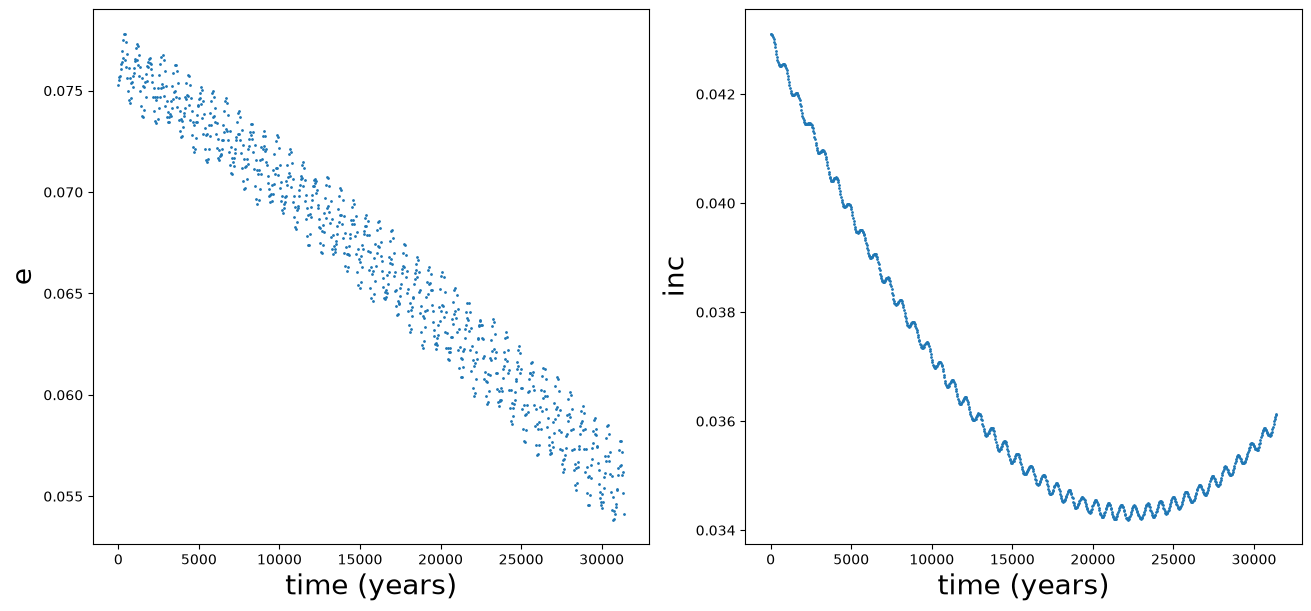

In [8]:
# plot
a_list = np.asarray(a_list)
e_list = np.asarray(e_list)
inc_list = np.asarray(inc_list)
Omega_list = np.asarray(Omega_list)
omega_list = np.asarray(omega_list)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 6), layout="constrained")

ax[0].scatter(time_list_year, e_list, s=1)
ax[0].set_xlabel("time (years)", fontsize = 20)
ax[0].set_ylabel("e", fontsize = 20)

ax[1].scatter(time_list_year, inc_list, s=1)
ax[1].set_xlabel("time (years)", fontsize = 20)
ax[1].set_ylabel("inc", fontsize = 20)

plt.show()

In [9]:
X_list = np.sqrt(2*(1-np.sqrt(1-e_list**2))) * np.exp(1j * omega_list)
Y_list = (1- e_list**2)**(0.25) * np.sin(0.5 * inc_list)* np.exp(1j * Omega_list)

ecc_fmft_results = fmft(time_list_year,X_list,14)
planet_e_freqs = np.array(list(ecc_fmft_results.keys()))
planet_e_freqs_arcsec_per_yr = planet_e_freqs * 60*60*180/np.pi * (2*np.pi)

inc_fmft_results = fmft(time_list_year,Y_list,8)
planet_inc_freqs = np.array(list(inc_fmft_results.keys()))
planet_inc_freqs_arcsec_per_yr = planet_inc_freqs * 60*60*180/np.pi * (2*np.pi)

print("")
print(d)
print("g")
print("-------")
for g in planet_e_freqs[:6]:
	print("{:+07.3f} \t {:0.6f} \t {:0.3f}".format(g * 60 * 60 * 180 / np.pi * (2 * np.pi), np.abs(ecc_fmft_results[g]), np.angle(ecc_fmft_results[g])))
print("s")
print("-------")
for g in planet_inc_freqs[:4]:
	print("{:+07.3f} \t {:0.6f} \t {:0.3f}".format(g * 60 * 60 * 180 / np.pi * (2 * np.pi), np.abs(inc_fmft_results[g]), np.angle(inc_fmft_results[g])))


K09WK5U
g
-------
+94.612 	 0.071148 	 1.231
-316.285 	 0.003875 	 2.536
-724.520 	 0.002309 	 2.212
-1142.800 	 0.001684 	 1.958
-1570.977 	 0.001291 	 1.779
-10222.095 	 0.001236 	 -2.390
s
-------
-63.675 	 0.018999 	 -0.106
-405.415 	 0.001779 	 0.547
-797.368 	 0.001191 	 0.246
-1209.471 	 0.000861 	 0.009
